# Modelo de Machine Learning — previsão diária de `qt_material`

**Objetivo:** prever `qt_material` por **dia × canal × categoria** com **14 dias de antecedência**, usando o que aprendemos na análise exploratória (`analise_exploratoria.ipynb`).

**Premissas acordadas**
- **Grão:** dia × canal (App, Site) × categoria, sem horário. O total do dia é a soma das séries.
- **Correções de dados** na query de modelagem: receita negativa com `ABS`, duas casas decimais com `ROUND`, categoria inválida recuperada quando só falta uma categoria naquela hora × canal.
- **Datas comemorativas:** flag ligada na semana anterior e no dia do evento (Black Friday, Natal, Ano Novo, Dia do Consumidor, Dia das Mães, Dia dos Namorados). As datas são calculadas por regra, então a próxima Black Friday já tem flag.
- **Campanhas:** flag informada pelo negócio. Por premissa: Black November (03 a 30/11/2025) e a campanha de maio (15 a 24/05/2026).
- **Desconto:** não conhecemos o desconto realizado no futuro, mas o time responsável informa a **taxa média de desconto prevista para cada dia**. No histórico usamos a taxa realizada do dia.
- **Validação faseada:** treina com cerca de 5 meses, prevê 2 semanas, acrescenta essas 2 semanas ao treino e repete até o fim da base.

**Roteiro:** 1. Base de modelagem · 2. Features · 3. Validação faseada · 4. Baselines · 5. Regressão linear · 6. LightGBM · 7. XGBoost · 8. Comparação · 9. SHAP · 10. Sensibilidade ao desconto · 11. Conclusões

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from gb_ml.io import estimate_query_bytes, read_query

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

PROJECT_ID = "gms-prod-01"
BQ_LOCATION = "us-east4"
TABLE_ID = "gms-prod-01.projeto_gb.fact_vendas"
STG_TABLE_ID = "gms-prod-01.projeto_gb.stg_fact_vendas"

START_DATE = "2025-11-01"
END_DATE = "2026-06-30"

DATE_FILTER = f"DATE(dt_hr_venda) BETWEEN DATE '{START_DATE}' AND DATE '{END_DATE}'"

# Validação faseada: o teste começa depois de 5 meses de treino
INICIO_TESTE = "2026-04-01"
# Ajuste de hiperparâmetros só com dados anteriores ao teste
INICIO_AJUSTE, FIM_AJUSTE = "2026-02-15", "2026-03-28"

COR_REAL = "#333333"
CORES_MODELO = {
    "naive_sazonal": "#9e9e9e",
    "mm7": "#bdbdbd",
    "mm28": "#757575",
    "regressao_linear": "#1f4e79",
    "lightgbm": "#6a994e",
    "xgboost": "#d17a22",
}

## Consumo BigQuery

Antes de cada consulta, fazemos um **dry-run** para estimar bytes processados. As consultas ficam na pasta `sql/`, numeradas na ordem de uso no projeto: este notebook continua a numeração da análise exploratória (`42_sql_base_modelagem.sql`, `43_sql_conferencia_modelagem.sql`).

In [2]:
from pathlib import Path


def run_bq(sql: str, label: str | None = None) -> pd.DataFrame:
    bytes_processed = estimate_query_bytes(sql, project_id=PROJECT_ID, location=BQ_LOCATION)
    mb = bytes_processed / 1024**2
    print(f"[BigQuery] {label or 'query'} | estimativa processada: {mb:,.2f} MB")
    return read_query(sql, project_id=PROJECT_ID, location=BQ_LOCATION)


PASTA_SQL = next(
    pasta / "sql" for pasta in [Path.cwd(), *Path.cwd().parents] if (pasta / "sql").is_dir()
)


def carregar_sql(arquivo: str, **parametros) -> str:
    """Lê sql/<arquivo> e preenche os parâmetros {TABLE_ID}, {DATE_FILTER} etc."""
    modelo = (PASTA_SQL / arquivo).read_text(encoding="utf-8")
    return modelo.format(
        TABLE_ID=TABLE_ID,
        STG_TABLE_ID=STG_TABLE_ID,
        DATE_FILTER=DATE_FILTER,
        START_DATE=START_DATE,
        END_DATE=END_DATE,
        **parametros,
    )

# 1. Base de modelagem

A query `42_sql_base_modelagem.sql` aplica as correções identificadas na análise exploratória e entrega o grão do modelo:

| Problema (seção da análise exploratória) | Correção |
|---|---|
| Receita negativa é erro de sinal (2.4) | `ABS(receita_aprovada)` |
| Valores monetários com mais de 2 casas (2.6) | `ROUND(..., 2)` em receita e desconto |
| Categoria com código numérico (2.3) | recebe a única categoria que falta naquela hora × canal; se houver 2 ou mais candidatas, vira `NAO_IDENTIFICADA` |
| Dias sem venda de uma série | grade completa dia × canal × categoria, com zero |

Ela também calcula `taxa_desconto_dia` = desconto ÷ (receita + desconto) do dia, somando todos os canais e categorias. É a mesma definição da análise exploratória e é o número que o time de desconto informaria para os dias futuros.

In [3]:
sql_base_modelagem = carregar_sql("42_sql_base_modelagem.sql")

base = run_bq(sql_base_modelagem, "base de modelagem: dia x canal x categoria")
base["data"] = pd.to_datetime(base["data"])
base["qt_material"] = base["qt_material"].astype(float)

print(f"{len(base):,} linhas | {base['data'].nunique()} dias | "
      f"{base.groupby(['des_canal_venda_final_agrup', 'des_categoria_material']).ngroups} séries")
display(base.head())

[BigQuery] base de modelagem: dia x canal x categoria | estimativa processada: 5.87 MB


4,356 linhas | 242 dias | 18 séries


,data,des_canal_venda_final_agrup,des_categoria_material,qt_material,receita_aprovada,vlr_venda_desconto,taxa_desconto_dia
0,2025-11-01,App,CABELOS,769.0000,"26,428.9400","6,110.8200",0.3653
1,2025-11-01,App,CORPO E BANHO,"3,386.0000","149,964.9600","63,001.6900",0.3653
2,2025-11-01,App,FACIAL,370.0000,"14,032.6200","9,897.4200",0.3653
3,2025-11-01,App,GIFTS,"1,725.0000","153,963.0300","69,794.1300",0.3653
4,2025-11-01,App,MAQUIAGEM,"2,393.0000","69,248.0000","48,388.1000",0.3653


### Conferência da base

A base corrigida precisa ter **o mesmo volume** da tabela original: as correções só redistribuem categorias e ajustam sinal e centavos, não podem criar nem perder `qt_material`.

In [4]:
sql_conferencia_modelagem = carregar_sql("43_sql_conferencia_modelagem.sql")
original = run_bq(sql_conferencia_modelagem, "totais da tabela original").iloc[0]

conferencia = pd.DataFrame({
    "tabela original": original[["qt_material", "receita_aprovada", "vlr_venda_desconto"]].astype(float),
    "base de modelagem": base[["qt_material", "receita_aprovada", "vlr_venda_desconto"]].sum(),
})
conferencia["diferença"] = conferencia["base de modelagem"] - conferencia["tabela original"]
display(conferencia)

qt_invalida = float(original["qt_categoria_invalida"])
qt_nao_identificada = base.loc[base["des_categoria_material"] == "NAO_IDENTIFICADA", "qt_material"].sum()
print(f"qt_material com categoria inválida: {qt_invalida:,.0f}")
print(f"recuperada para uma categoria:      {qt_invalida - qt_nao_identificada:,.0f} "
      f"({1 - qt_nao_identificada / qt_invalida:.1%})")
print(f"ficou como NAO_IDENTIFICADA:        {qt_nao_identificada:,.0f} "
      f"({qt_nao_identificada / base['qt_material'].sum():.1%} do volume total)")
assert abs(conferencia.loc["qt_material", "diferença"]) < 1e-6, "a base perdeu ou duplicou volume"

[BigQuery] totais da tabela original | estimativa processada: 5.41 MB


,tabela original,base de modelagem,diferença
qt_material,"9,896,201.0000","9,896,201.0000",0.0000
receita_aprovada,"532,413,485.7000","532,413,485.7000",0.0000
vlr_venda_desconto,"379,767,342.7800","379,767,342.7800",0.0000


qt_material com categoria inválida: 583,622
recuperada para uma categoria:      364,511 (62.5%)
ficou como NAO_IDENTIFICADA:        219,111 (2.2% do volume total)


### Diagnóstico

- **Volume preservado:** `qt_material`, receita e desconto batem exatamente com a tabela original. As correções não criaram nem perderam volume.
- **Categoria inválida:** 62,5% do volume com código numérico (364 mil de 584 mil unidades) foi recuperado para a única categoria possível. O restante (219 mil, 2,2% do volume total) ficou como `NAO_IDENTIFICADA` e é previsto como uma série própria. Assim o total do dia continua completo.
- **Grão final:** 242 dias × 2 canais × 9 categorias = 4.356 linhas, 18 séries sem buracos de datas.

# 2. Features

| Feature | Tipo | Por quê |
|---|---|---|
| `is_app` | dummy (App = 1, Site = 0) | nível de volume diferente por canal |
| `cat_*` | dummies de categoria | nível de volume diferente por categoria |
| `dia_semana` | 0 = segunda ... 6 = domingo (dummies na regressão linear) | padrão semanal forte (seção 1.5 da análise exploratória) |
| `dia_mes` | 1 a 31 (só nas árvores) | possível efeito de início/fim de mês |
| `evento_*` | 1 na semana anterior e no dia do evento | a alta começa antes da data |
| `campanha` | 1 no período informado pelo negócio | Black November e campanha de maio |
| `taxa_desconto_dia` | taxa média de desconto do dia | premissa: informada pelo time de desconto |
| `lag_14`, `lag_21`, `lag_28`, `mm7_lag14`, `mm28_lag14` | histórico da própria série (só nas árvores, testado como parâmetro) | nível recente da série; todos com pelo menos 14 dias de atraso, porque a previsão é feita 14 dias antes |

**Ficaram de fora:**
- **ano**: 2025 seria só novembro e dezembro, ou seja, um sinônimo de Black November.
- **mês**: cada mês aparece uma única vez na base, então o modelo decoraria o nível de cada mês.
- **`nr_pedidos` e receita do mesmo dia**: são resultado da venda, não estão disponíveis no momento da previsão.

In [5]:
from gb_ml.features import CAMPANHAS, COLUNAS_EVENTO, HORIZONTE, montar_features, tabela_eventos

df = montar_features(base)

eventos = tabela_eventos([2025, 2026])
eventos["na base"] = eventos["data"].between(START_DATE, END_DATE)
print("Datas comemorativas (a flag fica ligada de inicio_flag até fim_flag):")
display(eventos.sort_values("data").reset_index(drop=True))
print("Campanhas (premissa do negócio):")
display(pd.DataFrame(CAMPANHAS, columns=["campanha", "inicio", "fim"]))

Datas comemorativas (a flag fica ligada de inicio_flag até fim_flag):


,evento,data,inicio_flag,fim_flag,na base
0,ano_novo,2025-01-01,2024-12-25,2025-01-01,False
1,dia_consumidor,2025-03-15,2025-03-08,2025-03-15,False
2,dia_maes,2025-05-11,2025-05-04,2025-05-11,False
3,dia_namorados,2025-06-12,2025-06-05,2025-06-12,False
4,black_friday,2025-11-28,2025-11-21,2025-11-28,True
5,natal,2025-12-25,2025-12-18,2025-12-25,True
6,ano_novo,2026-01-01,2025-12-25,2026-01-01,True
7,dia_consumidor,2026-03-15,2026-03-08,2026-03-15,True
8,dia_maes,2026-05-10,2026-05-03,2026-05-10,True
9,dia_namorados,2026-06-12,2026-06-05,2026-06-12,True


Campanhas (premissa do negócio):


,campanha,inicio,fim
0,black_november,2025-11-03,2025-11-30
1,campanha_maio,2026-05-15,2026-05-24


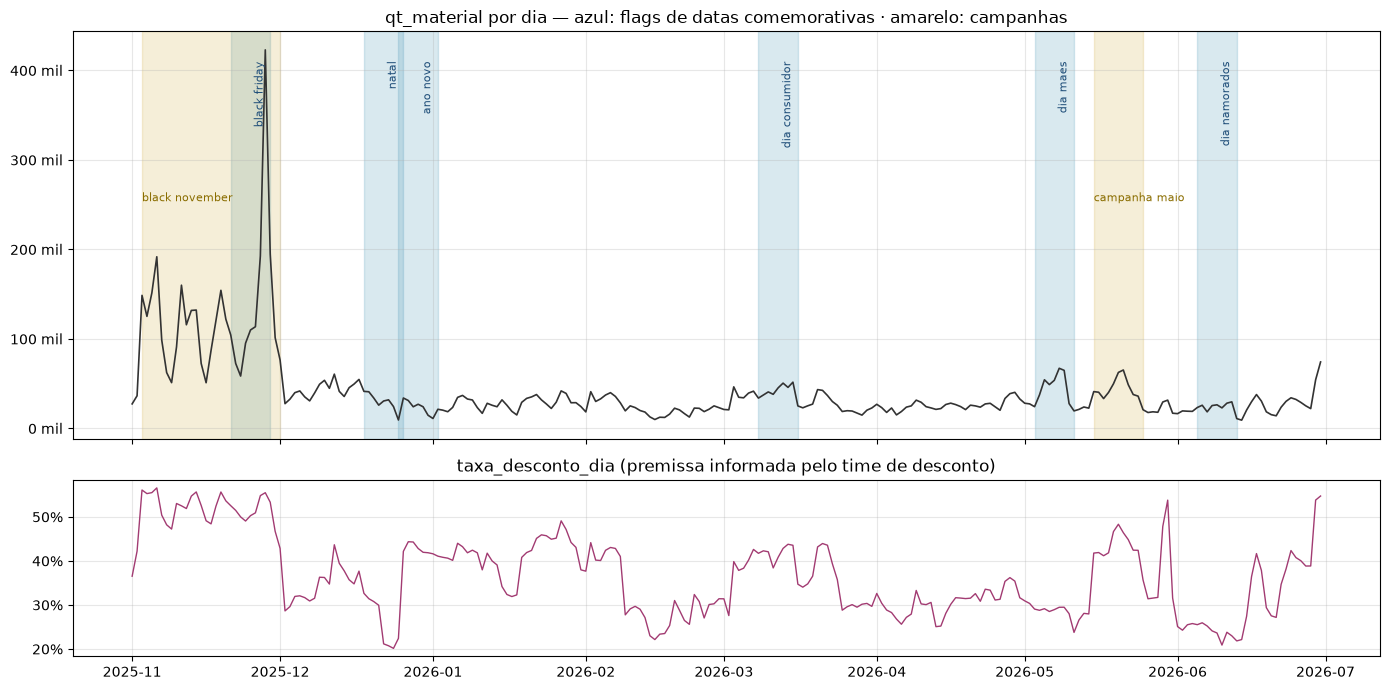

In [6]:
total_dia = df.groupby("data").agg(qt_material=("qt_material", "sum"), taxa_desconto_dia=("taxa_desconto_dia", "first"))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1.3]})
ax1.plot(total_dia.index, total_dia["qt_material"], color=COR_REAL, lw=1.2)
for _, ev in eventos[eventos["na base"]].iterrows():
    ax1.axvspan(ev["inicio_flag"], ev["fim_flag"] + pd.Timedelta(days=1), color="#2e86ab", alpha=0.18)
    ax1.text(ev["data"], total_dia["qt_material"].max() * 0.97, ev["evento"].replace("_", " "),
             rotation=90, va="top", ha="right", fontsize=8, color="#1f4e79")
for nome, inicio, fim in CAMPANHAS:
    ax1.axvspan(pd.Timestamp(inicio), pd.Timestamp(fim) + pd.Timedelta(days=1), color="#c9a227", alpha=0.18)
    ax1.text(pd.Timestamp(inicio), total_dia["qt_material"].max() * 0.6, nome.replace("_", " "),
             fontsize=8, color="#8a6d00")
ax1.set_title("qt_material por dia — azul: flags de datas comemorativas · amarelo: campanhas")
ax1.yaxis.set_major_formatter(lambda v, _: f"{v / 1000:,.0f} mil")
ax1.grid(alpha=0.3)

ax2.plot(total_dia.index, total_dia["taxa_desconto_dia"], color="#a23b72", lw=1)
ax2.set_title("taxa_desconto_dia (premissa informada pelo time de desconto)")
ax2.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Diagnóstico

- **Black November** domina o gráfico: o mês inteiro ficou de 3 a 4 vezes acima do resto da base, e a Black Friday (28/11) chegou a 423 mil. A flag `campanha` cobre o mês, e a flag `black_friday` cobre a semana do evento.
- **Desconto acompanha os picos:** novembro ficou acima de 50%, e a campanha de maio e o fim de junho também tiveram saltos. Por isso a taxa de desconto do dia é uma feature forte.
- **Dia das Mães** (03 a 10/05) aparece pela **primeira vez** dentro do período de teste. O modelo ainda não tem exemplo desse evento quando precisa prevê-lo (ver seção 8).

# 3. Validação faseada

Simula o uso real: em cada rodada o modelo treina com **tudo que aconteceu até a véspera**, prevê os **próximos 14 dias** e só depois recebe esses 14 dias para a rodada seguinte (janela expansível).

- **Ajuste de hiperparâmetros:** usa só dados até 28/03, com 3 rodadas de 14 dias entre 15/02 e 28/03. O período de teste não é usado para escolher parâmetros, para que o erro reportado não saia otimista.
- **Teste:** 7 rodadas de 01/04 a 30/06, com cerca de 5 meses de treino na primeira. A última rodada tem só 7 dias, porque a base termina em 30/06.
- **Métricas** (sempre sobre o período previsto):
  - **WAPE** = Σ|erro| ÷ Σ real, a métrica principal. É calculado em dois níveis: por série (dia × canal × categoria) e no total do dia.
  - **MAE** do total do dia, em unidades.
  - **Viés** = Σ(previsto − real) ÷ Σ real. Positivo significa que o modelo superestima.
  - **Skill** = 1 − WAPE do modelo ÷ WAPE do melhor baseline. Acima de zero, o modelo ganha do baseline.

Rodadas de ajuste de hiperparâmetros:


,rodada,inicio,fim
0,1,2026-02-15,2026-02-28
1,2,2026-03-01,2026-03-14
2,3,2026-03-15,2026-03-28


Rodadas de teste:


,rodada,inicio,fim,dias_de_treino
0,1,2026-04-01,2026-04-14,151
1,2,2026-04-15,2026-04-28,165
2,3,2026-04-29,2026-05-12,179
3,4,2026-05-13,2026-05-26,193
4,5,2026-05-27,2026-06-09,207
5,6,2026-06-10,2026-06-23,221
6,7,2026-06-24,2026-06-30,235


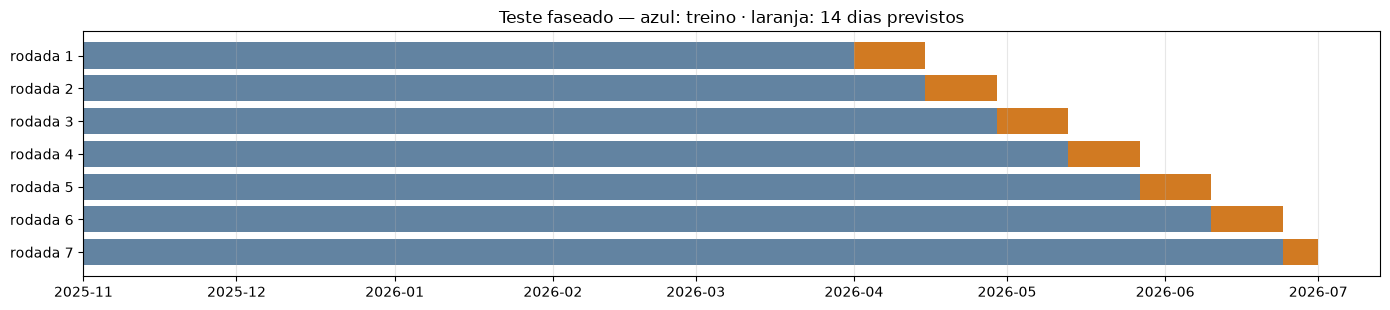

In [7]:
from gb_ml.model import (
    baseline, buscar_parametros, erro_por_rodada, gerar_folds, resumo_backtest, rodar_backtest,
)

folds_ajuste = gerar_folds(INICIO_AJUSTE, FIM_AJUSTE)
folds_teste = gerar_folds(INICIO_TESTE, END_DATE)

print("Rodadas de ajuste de hiperparâmetros:")
display(folds_ajuste)
print("Rodadas de teste:")
display(folds_teste.assign(dias_de_treino=(folds_teste["inicio"] - pd.Timestamp(START_DATE)).dt.days))

fig, ax = plt.subplots(figsize=(14, 3.2))
for i, f in folds_teste.iterrows():
    y = len(folds_teste) - i
    ax.barh(y, (f["inicio"] - pd.Timestamp(START_DATE)).days, left=pd.Timestamp(START_DATE), color="#1f4e79", alpha=0.7)
    ax.barh(y, (f["fim"] - f["inicio"]).days + 1, left=f["inicio"], color="#d17a22")
ax.set_yticks(range(1, len(folds_teste) + 1), [f"rodada {r}" for r in folds_teste["rodada"][::-1]])
ax.set_title("Teste faseado — azul: treino · laranja: 14 dias previstos")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Baselines

Referências simples, calculadas por série com o histórico até a véspera de cada rodada (as médias móveis vêm da análise exploratória):
- **naive_sazonal**: repete a última semana observada, mantendo o dia da semana;
- **mm7** e **mm28**: média dos últimos 7 e 28 dias, constante nos 14 dias.

Um modelo só se justifica se tiver erro menor que o do melhor baseline.

In [8]:
previsoes = {}
for metodo in ["naive_sazonal", "mm7", "mm28"]:
    previsoes[metodo] = rodar_backtest(df, folds_teste, baseline(metodo))

resumo_baselines = pd.DataFrame({m: resumo_backtest(p) for m, p in previsoes.items()}).T
display(resumo_baselines)
MELHOR_BASELINE = resumo_baselines["wape_dia"].idxmin()
print(f"Melhor baseline (WAPE do total do dia): {MELHOR_BASELINE}")

,wape_serie,wape_dia,mae_dia,vies_dia
naive_sazonal,0.5699,0.4113,"12,107.6593",-0.0027
mm7,0.5147,0.3576,"10,525.9011",-0.0027
mm28,0.5241,0.3868,"11,384.5137",0.0169


Melhor baseline (WAPE do total do dia): mm7


# 5. Regressão linear

Regressão linear (mínimos quadrados) com todas as features em dummies e erros-padrão robustos (HC1). Usa as features de calendário, eventos, campanha, desconto, canal e categoria, sem lags. Assim cada coeficiente é um efeito direto e interpretável.

**Parâmetros testados**
- `alvo`:
  - `log`: modela `log(1 + qt_material)`. Os efeitos ficam multiplicativos ("a semana da Black Friday multiplica o volume por X"), o que funciona para qualquer nível de vendas.
  - `nivel`: modela `qt_material` direto, com efeitos em unidades.
- `interacao`: inclui ou não uma interação canal × categoria (cada categoria com um nível próprio por canal).

In [9]:
from gb_ml.model import ajustar_linear, linear

grade_linear = {"alvo": ["log", "nivel"], "interacao": [False, True]}
busca_linear = buscar_parametros(df, folds_ajuste, linear, grade_linear)
display(busca_linear)

params_linear = busca_linear.iloc[0][list(grade_linear)].to_dict()
print("Melhor combinação:", params_linear)
previsoes["regressao_linear"] = rodar_backtest(df, folds_teste, linear(**params_linear))
display(pd.DataFrame({"regressao_linear": resumo_backtest(previsoes["regressao_linear"])}).T)

,alvo,interacao,wape_serie,wape_dia,mae_dia,vies_dia
0,log,False,0.3961,0.2375,"6,717.2832",-0.1221
1,log,True,0.3984,0.2358,"6,670.5674",-0.1040
2,nivel,True,0.6385,0.2740,"7,750.1664",0.1633
3,nivel,False,0.6688,0.3343,"9,455.4946",0.2728


Melhor combinação: {'alvo': 'log', 'interacao': False}


,wape_serie,wape_dia,mae_dia,vies_dia
regressao_linear,0.4806,0.3102,"9,130.2520",-0.0379


### Curva: real × previsto no teste faseado

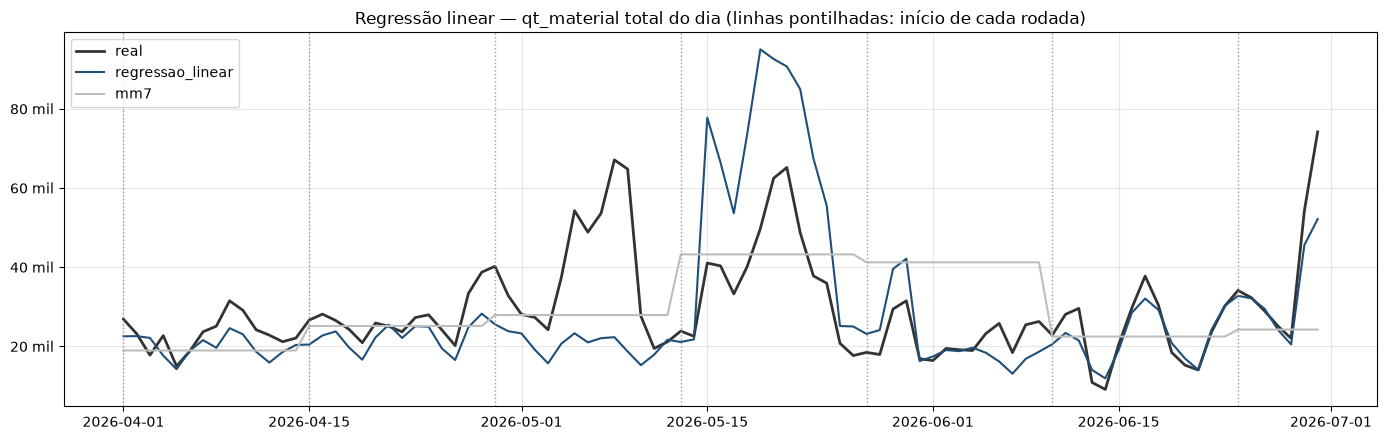

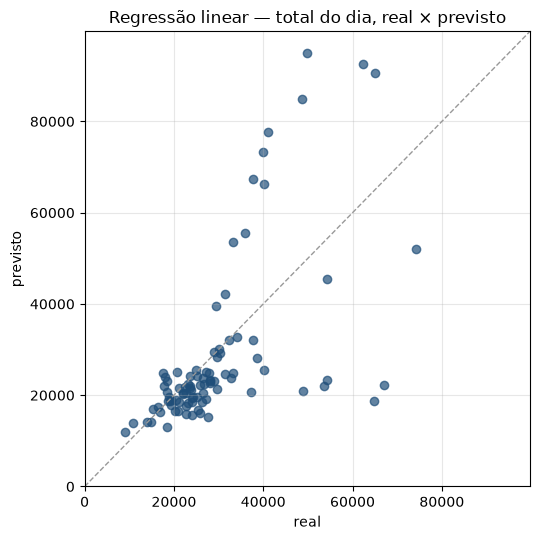

In [10]:
def plot_real_previsto(modelos: list[str], titulo: str) -> None:
    """Total do dia: real × previsto por modelo, com as divisões das rodadas."""
    fig, ax = plt.subplots(figsize=(14, 4.5))
    real = previsoes[modelos[0]].groupby("data")["qt_material"].sum()
    ax.plot(real.index, real, color=COR_REAL, lw=2, label="real")
    for modelo in modelos:
        previsto = previsoes[modelo].groupby("data")["previsto"].sum()
        ax.plot(previsto.index, previsto, color=CORES_MODELO[modelo], lw=1.5, label=modelo)
    for inicio in folds_teste["inicio"]:
        ax.axvline(inicio, color="#999999", ls=":", lw=1)
    ax.set_title(titulo)
    ax.yaxis.set_major_formatter(lambda v, _: f"{v / 1000:,.0f} mil")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_real_previsto(["regressao_linear", MELHOR_BASELINE],
                   "Regressão linear — qt_material total do dia (linhas pontilhadas: início de cada rodada)")

total_linear = previsoes["regressao_linear"].groupby("data")[["qt_material", "previsto"]].sum()
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(total_linear["qt_material"], total_linear["previsto"], color=CORES_MODELO["regressao_linear"], alpha=0.7)
limite = total_linear.to_numpy().max() * 1.05
ax.plot([0, limite], [0, limite], color="#999999", ls="--", lw=1)
ax.set(xlim=(0, limite), ylim=(0, limite), xlabel="real", ylabel="previsto",
       title="Regressão linear — total do dia, real × previsto")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Resultados estatísticos da regressão

Modelo final ajustado com **toda a base** (01/11 a 30/06), com a melhor combinação de parâmetros. Para o alvo em log, **efeito %** = e^coeficiente − 1 é a variação de volume quando a feature vale 1, mantendo as demais constantes. Para `taxa_desconto_dia`, o efeito é para **+10 pontos percentuais** de desconto.

In [11]:
modelo_linear = ajustar_linear(df, **params_linear)
print(f"R² = {modelo_linear.rsquared:.3f} | R² ajustado = {modelo_linear.rsquared_adj:.3f} | "
      f"n = {int(modelo_linear.nobs):,} | alvo = {params_linear['alvo']}")

ic = modelo_linear.conf_int()
coeficientes = pd.DataFrame({
    "coeficiente": modelo_linear.params,
    "ic95_inf": ic[0],
    "ic95_sup": ic[1],
    "p_valor": modelo_linear.pvalues,
})
escala = pd.Series(1.0, index=coeficientes.index)
escala["taxa_desconto_dia"] = 0.10  # efeito de +10 p.p. de desconto
if params_linear["alvo"] == "log":
    for coluna in ["coeficiente", "ic95_inf", "ic95_sup"]:
        coeficientes[f"efeito_%_{coluna}"] = np.expm1(coeficientes[coluna] * escala)
coeficientes["significativo_5%"] = coeficientes["p_valor"] < 0.05
display(coeficientes.drop(index="const"))

R² = 0.711 | R² ajustado = 0.709 | n = 4,356 | alvo = log


,coeficiente,ic95_inf,ic95_sup,p_valor,efeito_%_coeficiente,efeito_%_ic95_inf,efeito_%_ic95_sup,significativo_5%
is_app,1.1919,1.1443,1.2394,0.0000,2.2933,2.1404,2.4537,True
taxa_desconto_dia,3.2570,2.8685,3.6454,0.0000,0.3850,0.3322,0.4398,True
evento_ano_novo,-0.5132,-0.6439,-0.3826,0.0000,-0.4015,-0.4748,-0.3179,True
evento_dia_consumidor,0.1706,0.0209,0.3203,0.0255,0.1860,0.0211,0.3775,True
evento_dia_maes,0.5820,0.4589,0.7050,0.0000,0.7896,0.5824,1.0239,True
evento_dia_namorados,0.3050,0.2019,0.4081,0.0000,0.3566,0.2237,0.5040,True
evento_black_friday,0.2857,0.0843,0.4871,0.0054,0.3307,0.0880,0.6276,True
evento_natal,0.3574,0.2279,0.4869,0.0000,0.4296,0.2560,0.6273,True
campanha,0.6737,0.5719,0.7755,0.0000,0.9615,0.7717,1.1717,True
dia_semana_1,0.1083,0.0252,0.1915,0.0106,0.1144,0.0255,0.2110,True


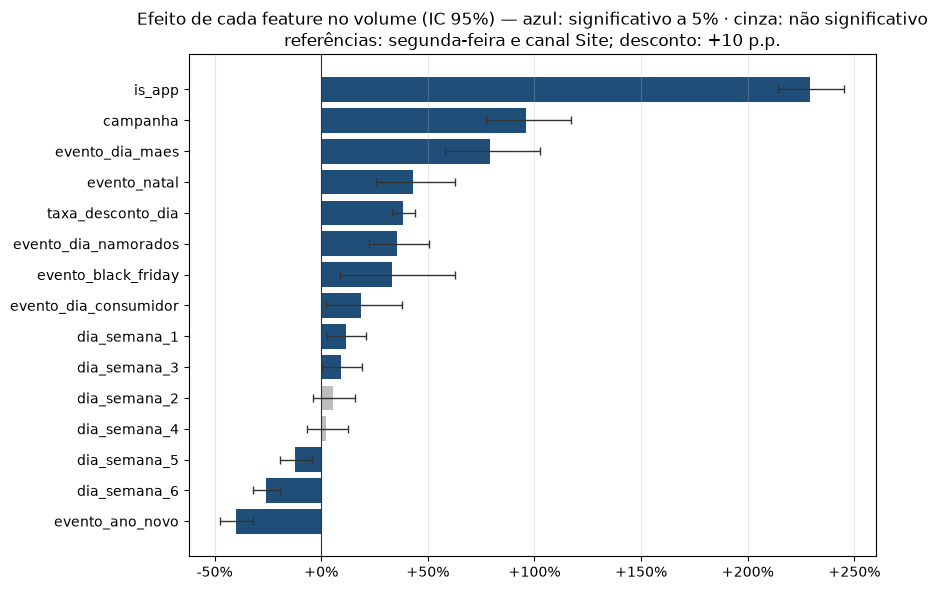

In [12]:
grupos_coef = [c for c in coeficientes.index if c.startswith(("evento_", "campanha", "taxa_", "dia_semana_", "is_app"))]
efeito = coeficientes.loc[grupos_coef]
coluna = "efeito_%_coeficiente" if params_linear["alvo"] == "log" else "coeficiente"
inf = "efeito_%_ic95_inf" if params_linear["alvo"] == "log" else "ic95_inf"
sup = "efeito_%_ic95_sup" if params_linear["alvo"] == "log" else "ic95_sup"
efeito = efeito.sort_values(coluna)

fig, ax = plt.subplots(figsize=(9, 6))
cores_barra = np.where(efeito["significativo_5%"], "#1f4e79", "#bdbdbd")
ax.barh(efeito.index, efeito[coluna], color=cores_barra)
ax.errorbar(efeito[coluna], efeito.index, xerr=[efeito[coluna] - efeito[inf], efeito[sup] - efeito[coluna]],
            fmt="none", ecolor="#333333", lw=1, capsize=3)
ax.axvline(0, color="#333333", lw=0.8)
if params_linear["alvo"] == "log":
    ax.xaxis.set_major_formatter(lambda v, _: f"{v:+.0%}")
ax.set_title("Efeito de cada feature no volume (IC 95%) — azul: significativo a 5% · cinza: não significativo\n"
             "referências: segunda-feira e canal Site; desconto: +10 p.p.")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Diagnóstico

- **Melhor combinação:** alvo em `log`, sem interação. Em nível, a regressão erra muito mais (WAPE da série 0,64–0,67 contra 0,40), porque o volume de novembro é 4× o do resto da base e os efeitos são proporcionais, não somados.
- **Teste faseado:** WAPE do total do dia de **31,0%**, contra 35,8% do melhor baseline (mm7), com viés de −3,8%. É o modelo com menor viés.
- **Ajuste com toda a base:** R² = 0,71 (em log). Todos os eventos e a campanha são significativos a 5%. Leitura dos efeitos, mantendo o resto constante:
  - **desconto:** +10 p.p. → **+38%** de volume;
  - **campanha:** **+96%**;
  - **Dia das Mães:** +79%; **Natal:** +43%; **Black Friday:** +33% além da campanha de novembro; **Ano Novo:** −40%;
  - **sábado e domingo:** −12% e −26% em relação à segunda-feira.
- **Onde erra:**
  - **Campanha de maio superestimada** (previu até 95 mil para um pico real de 65 mil). O coeficiente de `campanha` foi aprendido quase só com a Black November, que foi muito mais forte.
  - **Dia das Mães subestimado.** No teste, o evento ainda não tinha acontecido no treino.
- **Dia dos Namorados:** sai com +36%. No gráfico não há pico visível, mas a taxa de desconto daquela semana foi a menor da base (~22%). Ou seja, o volume veio acima do que o desconto baixo indicaria. Com uma única ocorrência, isso é indicativo, não conclusivo.

# 6. LightGBM

Boosting de árvores: cada árvore nova corrige o erro das anteriores. Usa as mesmas features da regressão (com dia da semana e dia do mês numéricos) e pode usar os lags.

**Parâmetros testados** (todas as combinações, nas 3 rodadas de ajuste):
- `num_leaves`: número máximo de folhas por árvore (complexidade de cada árvore);
- `learning_rate` e `n_estimators`: tamanho do passo e número de árvores;
- `min_child_samples`: mínimo de linhas por folha (evita folhas que decoram poucos dias);
- `alvo`: `log` (erro quadrático em log(1 + qt)) ou `poisson` (objetivo próprio para contagem);
- `usar_lags`: com ou sem o histórico da própria série.

In [13]:
from gb_ml.model import lightgbm

grade_lightgbm = {
    "alvo": ["log", "poisson"],
    "usar_lags": [False, True],
    "num_leaves": [7, 15, 31],
    "learning_rate": [0.03, 0.1],
    "n_estimators": [200, 500],
    "min_child_samples": [10, 40],
}
busca_lightgbm = buscar_parametros(df, folds_ajuste, lightgbm, grade_lightgbm)
print(f"{len(busca_lightgbm)} combinações testadas. As 10 melhores:")
display(busca_lightgbm.head(10))

params_lightgbm = busca_lightgbm.iloc[0][list(grade_lightgbm)].to_dict()
for chave in ["num_leaves", "max_depth", "n_estimators", "min_child_samples", "min_child_weight"]:
    if chave in params_lightgbm:
        params_lightgbm[chave] = int(params_lightgbm[chave])
params_lightgbm["usar_lags"] = bool(params_lightgbm["usar_lags"])
print("Melhor combinação:", params_lightgbm)

previsoes["lightgbm"] = rodar_backtest(df, folds_teste, lightgbm(**params_lightgbm))
display(pd.DataFrame({"lightgbm": resumo_backtest(previsoes["lightgbm"])}).T)

96 combinações testadas. As 10 melhores:


,alvo,usar_lags,num_leaves,learning_rate,n_estimators,min_child_samples,wape_serie,wape_dia,mae_dia,vies_dia
0,log,False,31,0.0300,200,40,0.3689,0.2255,"6,377.9511",-0.0607
1,log,False,15,0.0300,200,10,0.3697,0.2327,"6,582.7708",-0.0919
2,log,False,7,0.0300,500,10,0.3715,0.2360,"6,675.7947",-0.1055
3,log,False,15,0.0300,200,40,0.3753,0.2390,"6,760.6094",-0.0816
4,log,False,7,0.0300,500,40,0.3754,0.2479,"7,010.8551",-0.1189
5,log,False,15,0.0300,500,10,0.3779,0.2336,"6,608.4610",-0.0663
6,log,False,7,0.1000,200,40,0.3787,0.2466,"6,974.8990",-0.0869
7,log,False,7,0.1000,200,10,0.3792,0.2402,"6,795.1642",-0.0820
8,log,False,31,0.0300,200,10,0.3807,0.2381,"6,734.3897",-0.0596
9,log,False,15,0.0300,500,40,0.3828,0.2370,"6,704.6077",-0.0481


Melhor combinação: {'alvo': 'log', 'usar_lags': False, 'num_leaves': 31, 'learning_rate': 0.03, 'n_estimators': 200, 'min_child_samples': 40}


,wape_serie,wape_dia,mae_dia,vies_dia
lightgbm,0.4156,0.2704,"7,959.2524",-0.1049


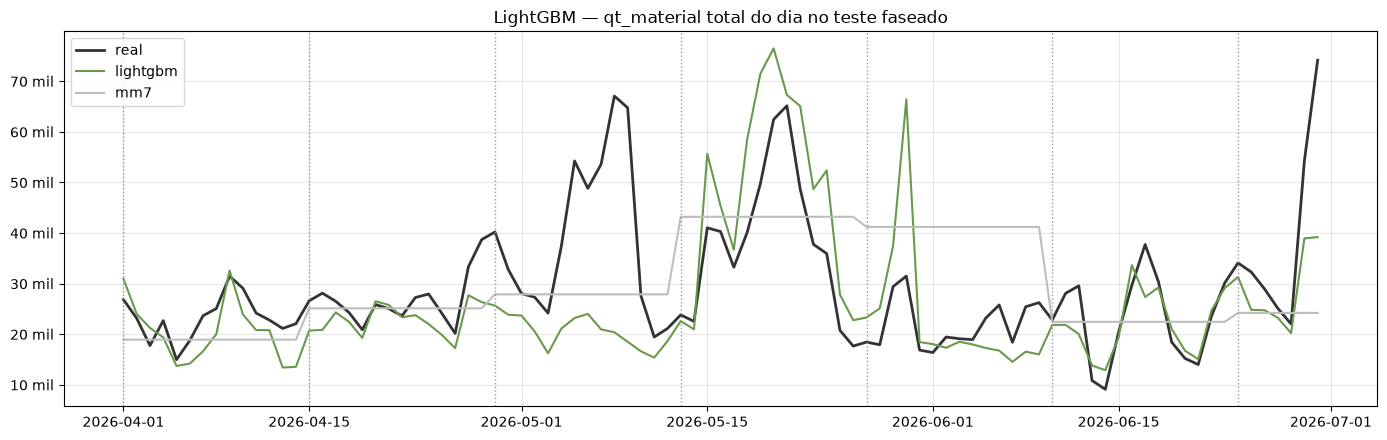

In [14]:
plot_real_previsto(["lightgbm", MELHOR_BASELINE], "LightGBM — qt_material total do dia no teste faseado")

### Esboço da árvore

O LightGBM final soma centenas de árvores, então desenhar uma delas diz pouco. Para ter um esboço legível do que o modelo aprendeu, ajustamos uma **árvore substituta** de 3 níveis que imita as previsões do LightGBM. A fidelidade (R²) mostra quanto do comportamento do modelo esse esboço captura. Os valores nas folhas estão em `qt_material` por série e dia.

Fidelidade da árvore substituta (R² contra as previsões do LightGBM): 0.58


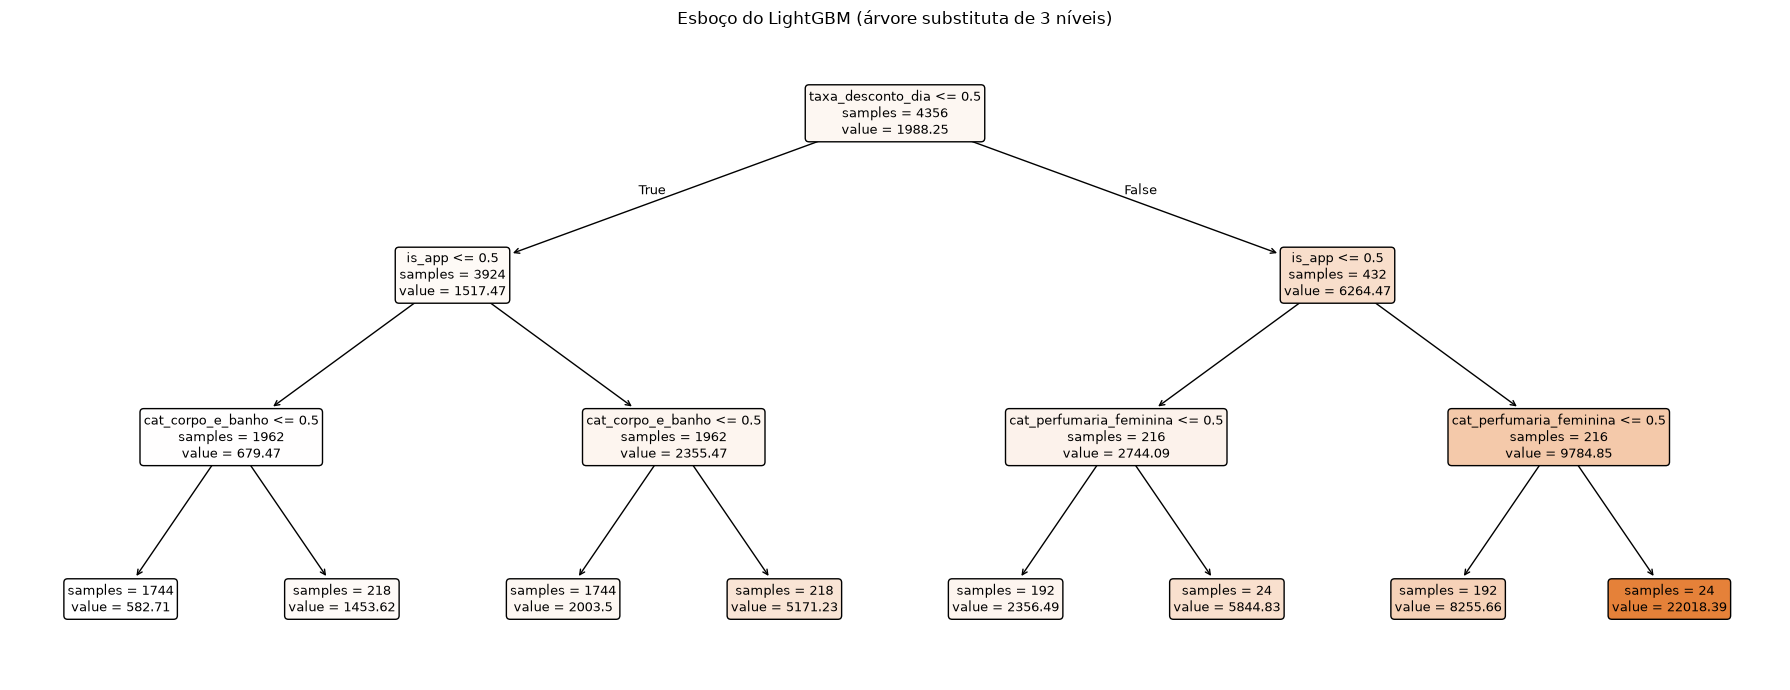

In [15]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

from gb_ml.features import matriz_arvore
from gb_ml.model import criar_lightgbm

params_modelo = {k: v for k, v in params_lightgbm.items() if k not in ("alvo", "usar_lags")}
X_lightgbm = matriz_arvore(df, params_lightgbm["usar_lags"])
y_lightgbm = np.log1p(df["qt_material"]) if params_lightgbm["alvo"] == "log" else df["qt_material"]
modelo_lightgbm = criar_lightgbm(params_lightgbm["alvo"], **params_modelo).fit(X_lightgbm, y_lightgbm)

previsto_lightgbm = modelo_lightgbm.predict(X_lightgbm)
if params_lightgbm["alvo"] == "log":
    previsto_lightgbm = np.expm1(previsto_lightgbm)
X_esboco = X_lightgbm.fillna(-1)
esboco = DecisionTreeRegressor(max_depth=3, random_state=42).fit(X_esboco, previsto_lightgbm)
print(f"Fidelidade da árvore substituta (R² contra as previsões do LightGBM): "
      f"{esboco.score(X_esboco, previsto_lightgbm):.2f}")

fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(esboco, feature_names=list(X_esboco.columns), filled=True, rounded=True,
          impurity=False, precision=2, fontsize=9, ax=ax)
ax.set_title("Esboço do LightGBM (árvore substituta de 3 níveis)")
plt.tight_layout()
plt.show()

### Diagnóstico

- **Melhor combinação:** alvo `log`, **sem lags**, 31 folhas, `learning_rate` 0,03, 200 árvores, `min_child_samples` 40. As 10 melhores combinações são todas sem lags. O histórico de 14 a 28 dias atrás atrapalha, porque a série muda de patamar com campanhas e eventos (a Black November contamina os lags de dezembro).
- **Teste faseado:** WAPE do total do dia de **27,0%**, o menor entre os modelos (skill de 24% sobre o mm7). Viés de −10,5%: subestima, principalmente na semana do Dia das Mães.
- **Esboço da árvore:** a primeira decisão é a **taxa de desconto do dia**, seguida de **canal** (App vende mais) e de **categoria** (Perfumaria Feminina e Corpo e Banho são as maiores). A árvore substituta explica 58% do comportamento do modelo. O resto vem de interações mais finas (dia da semana, eventos, campanha).
- **Ponto fraco:** a árvore reage forte a picos de desconto. Em 29–30/05 o desconto subiu para 48–54% e o modelo previu ~70 mil para um real de ~30 mil.

# 7. XGBoost

Boosting de árvores: cada árvore nova corrige o erro das anteriores. Usa as mesmas features da regressão (com dia da semana e dia do mês numéricos) e pode usar os lags.

**Parâmetros testados** (todas as combinações, nas 3 rodadas de ajuste):
- `max_depth`: profundidade máxima de cada árvore;
- `learning_rate` e `n_estimators`: tamanho do passo e número de árvores;
- `min_child_weight`: peso mínimo por folha (evita folhas que decoram poucos dias);
- `alvo`: `log` (erro quadrático em log(1 + qt)) ou `poisson` (objetivo próprio para contagem);
- `usar_lags`: com ou sem o histórico da própria série.

In [16]:
from gb_ml.model import xgboost

grade_xgboost = {
    "alvo": ["log", "poisson"],
    "usar_lags": [False, True],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.1],
    "n_estimators": [200, 500],
    "min_child_weight": [1, 10],
}
busca_xgboost = buscar_parametros(df, folds_ajuste, xgboost, grade_xgboost)
print(f"{len(busca_xgboost)} combinações testadas. As 10 melhores:")
display(busca_xgboost.head(10))

params_xgboost = busca_xgboost.iloc[0][list(grade_xgboost)].to_dict()
for chave in ["num_leaves", "max_depth", "n_estimators", "min_child_samples", "min_child_weight"]:
    if chave in params_xgboost:
        params_xgboost[chave] = int(params_xgboost[chave])
params_xgboost["usar_lags"] = bool(params_xgboost["usar_lags"])
print("Melhor combinação:", params_xgboost)

previsoes["xgboost"] = rodar_backtest(df, folds_teste, xgboost(**params_xgboost))
display(pd.DataFrame({"xgboost": resumo_backtest(previsoes["xgboost"])}).T)

96 combinações testadas. As 10 melhores:


,alvo,usar_lags,max_depth,learning_rate,n_estimators,min_child_weight,wape_serie,wape_dia,mae_dia,vies_dia
0,log,False,3,0.1000,200,10,0.3706,0.2314,"6,544.3184",-0.0945
1,log,False,3,0.1000,200,1,0.3709,0.2291,"6,480.6742",-0.0975
2,log,False,3,0.0300,500,10,0.3713,0.2302,"6,510.8915",-0.1062
3,log,False,3,0.0300,500,1,0.3755,0.2393,"6,767.7621",-0.0993
4,log,False,5,0.0300,200,10,0.3796,0.2518,"7,123.1420",-0.1112
5,log,False,5,0.0300,200,1,0.3811,0.2435,"6,887.1757",-0.1082
6,log,False,3,0.1000,500,1,0.3824,0.2445,"6,916.9477",-0.0877
7,log,False,3,0.1000,500,10,0.3877,0.2502,"7,077.6829",-0.0698
8,log,False,5,0.0300,500,10,0.3932,0.2574,"7,282.2622",-0.0844
9,log,False,5,0.0300,500,1,0.3960,0.2471,"6,988.4679",-0.0770


Melhor combinação: {'alvo': 'log', 'usar_lags': False, 'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 200, 'min_child_weight': 10}


,wape_serie,wape_dia,mae_dia,vies_dia
xgboost,0.4238,0.2893,"8,516.6270",-0.0884


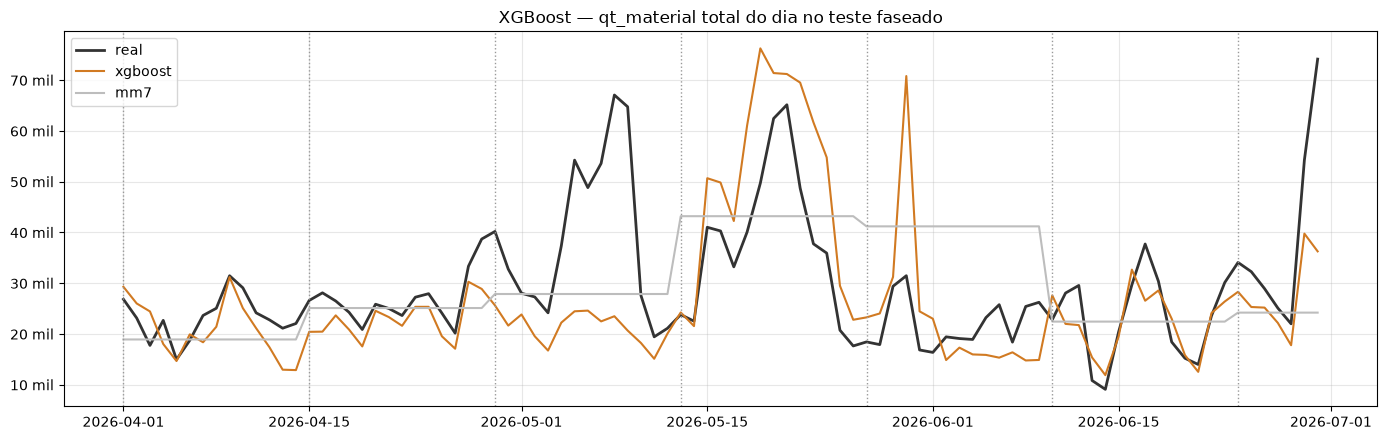

In [17]:
plot_real_previsto(["xgboost", MELHOR_BASELINE], "XGBoost — qt_material total do dia no teste faseado")

### Esboço da árvore

O XGBoost final soma centenas de árvores, então desenhar uma delas diz pouco. Para ter um esboço legível do que o modelo aprendeu, ajustamos uma **árvore substituta** de 3 níveis que imita as previsões do XGBoost. A fidelidade (R²) mostra quanto do comportamento do modelo esse esboço captura. Os valores nas folhas estão em `qt_material` por série e dia.

Fidelidade da árvore substituta (R² contra as previsões do XGBoost): 0.52


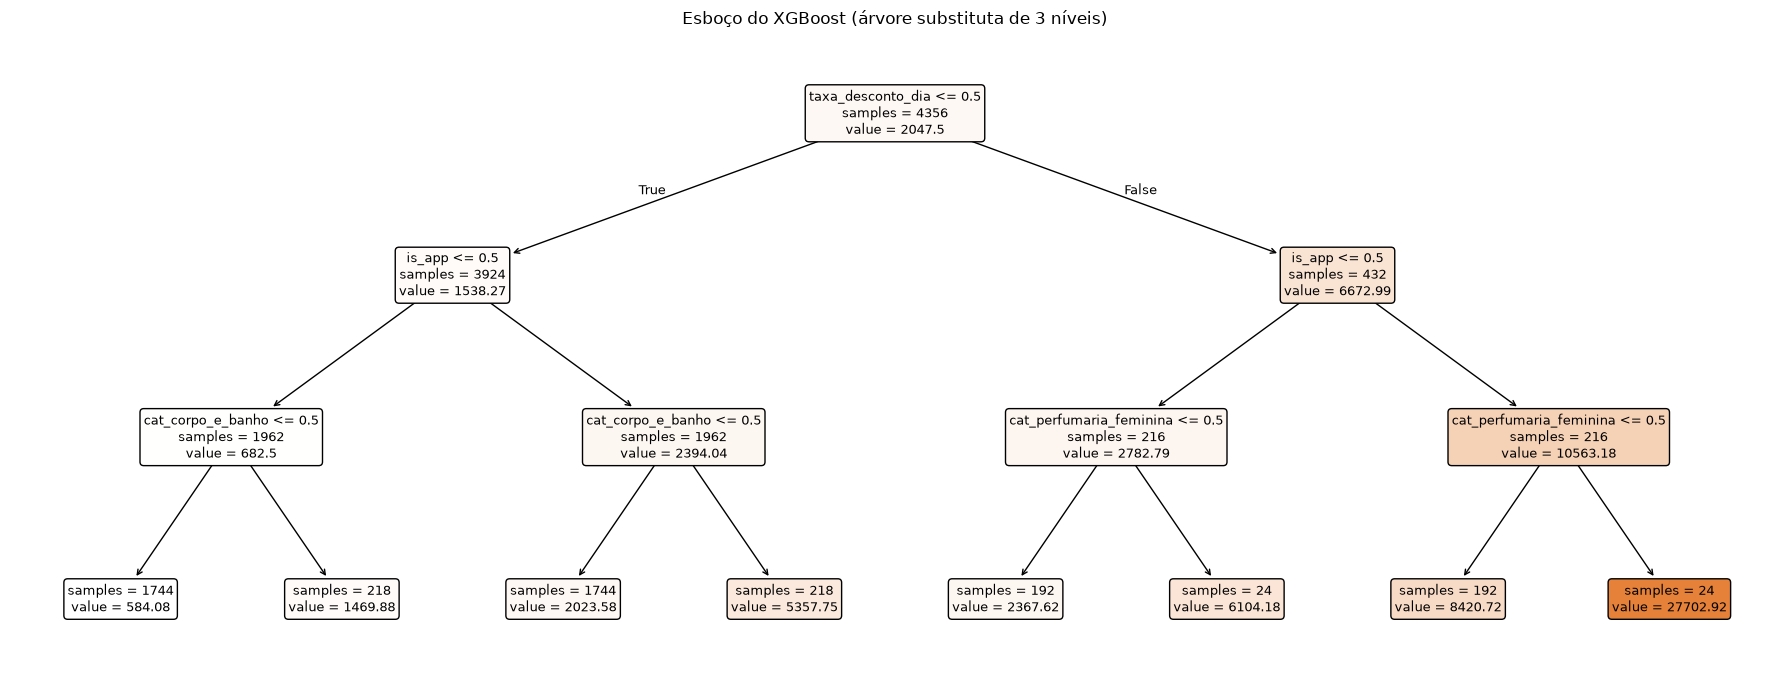

In [18]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

from gb_ml.features import matriz_arvore
from gb_ml.model import criar_xgboost

params_modelo = {k: v for k, v in params_xgboost.items() if k not in ("alvo", "usar_lags")}
X_xgboost = matriz_arvore(df, params_xgboost["usar_lags"])
y_xgboost = np.log1p(df["qt_material"]) if params_xgboost["alvo"] == "log" else df["qt_material"]
modelo_xgboost = criar_xgboost(params_xgboost["alvo"], **params_modelo).fit(X_xgboost, y_xgboost)

previsto_xgboost = modelo_xgboost.predict(X_xgboost)
if params_xgboost["alvo"] == "log":
    previsto_xgboost = np.expm1(previsto_xgboost)
X_esboco = X_xgboost.fillna(-1)
esboco = DecisionTreeRegressor(max_depth=3, random_state=42).fit(X_esboco, previsto_xgboost)
print(f"Fidelidade da árvore substituta (R² contra as previsões do XGBoost): "
      f"{esboco.score(X_esboco, previsto_xgboost):.2f}")

fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(esboco, feature_names=list(X_esboco.columns), filled=True, rounded=True,
          impurity=False, precision=2, fontsize=9, ax=ax)
ax.set_title("Esboço do XGBoost (árvore substituta de 3 níveis)")
plt.tight_layout()
plt.show()

### Diagnóstico

- **Melhor combinação:** alvo `log`, **sem lags**, árvores rasas (`max_depth` 3), `learning_rate` 0,1, 200 árvores, `min_child_weight` 10. Também prefere modelos simples, coerente com a base pequena (242 dias).
- **Teste faseado:** WAPE do total do dia de **28,9%** (skill de 19% sobre o mm7), com viés de −8,8%.
- **Esboço da árvore:** mesma lógica do LightGBM (desconto → canal → categoria), com fidelidade de 52%.
- O comportamento é muito parecido com o do LightGBM, incluindo os mesmos acertos e os mesmos erros (Dia das Mães, pico de desconto em 29–30/05).

# 8. Comparação dos modelos

Todos avaliados nas mesmas 7 rodadas de teste (01/04 a 30/06), com os parâmetros escolhidos só no período de ajuste.

**Quality gate** para seguir com um modelo: skill > 0 contra o melhor baseline e |viés| < 10% no total do dia.

In [19]:
comparacao = pd.DataFrame({m: resumo_backtest(p) for m, p in previsoes.items()}).T
comparacao["skill_vs_baseline"] = 1 - comparacao["wape_dia"] / comparacao.loc[MELHOR_BASELINE, "wape_dia"]
comparacao["passa_no_gate"] = (comparacao["skill_vs_baseline"] > 0) & (comparacao["vies_dia"].abs() < 0.10)
comparacao = comparacao.sort_values("wape_dia")
display(comparacao)
MELHOR_MODELO = comparacao.drop(index=["naive_sazonal", "mm7", "mm28"]).index[0]
print(f"Melhor modelo no teste: {MELHOR_MODELO}")

,wape_serie,wape_dia,mae_dia,vies_dia,skill_vs_baseline,passa_no_gate
lightgbm,0.4156,0.2704,"7,959.2524",-0.1049,0.2438,False
xgboost,0.4238,0.2893,"8,516.6270",-0.0884,0.1909,True
regressao_linear,0.4806,0.3102,"9,130.2520",-0.0379,0.1326,True
mm7,0.5147,0.3576,"10,525.9011",-0.0027,0.0000,False
mm28,0.5241,0.3868,"11,384.5137",0.0169,-0.0816,False
naive_sazonal,0.5699,0.4113,"12,107.6593",-0.0027,-0.1503,False


Melhor modelo no teste: lightgbm


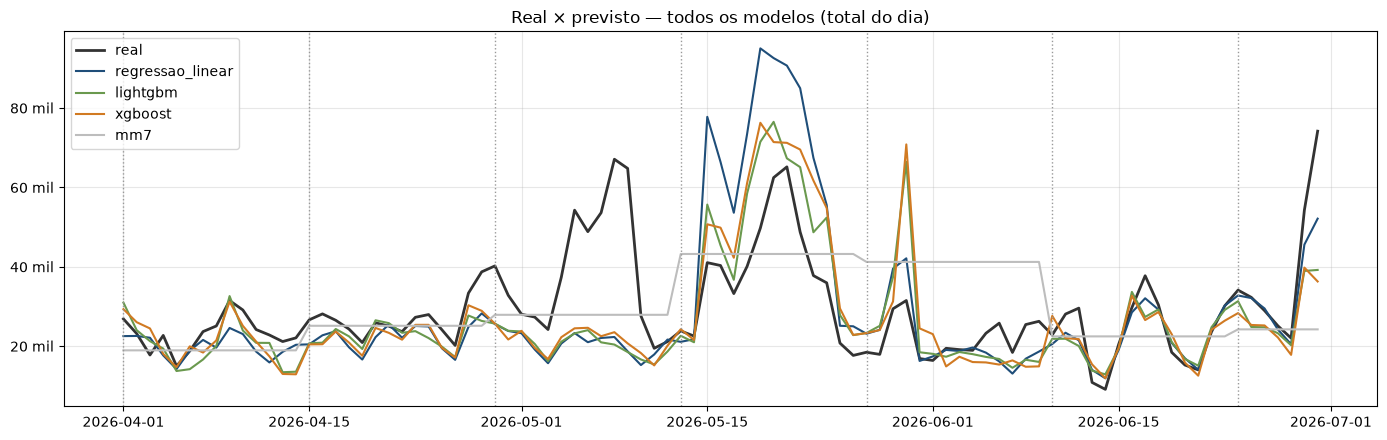

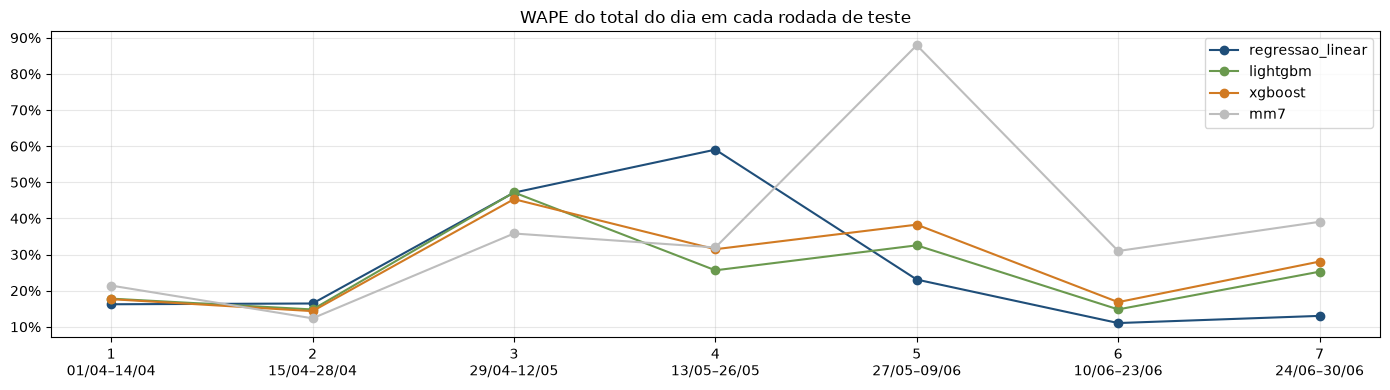

,regressao_linear,lightgbm,xgboost,mm7
rodada,,,,
1,0.1624,0.1780,0.1765,0.2141
2,0.1645,0.1480,0.1434,0.1235
3,0.4714,0.4719,0.4533,0.3582
4,0.5904,0.2563,0.3147,0.3196
5,0.2307,0.3255,0.3827,0.8794
6,0.1104,0.1481,0.1683,0.3098
7,0.1302,0.2526,0.2806,0.3906


In [20]:
modelos_ml = ["regressao_linear", "lightgbm", "xgboost"]
plot_real_previsto([*modelos_ml, MELHOR_BASELINE], "Real × previsto — todos os modelos (total do dia)")

fig, ax = plt.subplots(figsize=(14, 4))
for modelo in [*modelos_ml, MELHOR_BASELINE]:
    rodadas = erro_por_rodada(previsoes[modelo])
    ax.plot(rodadas["rodada"], rodadas["wape"], marker="o", color=CORES_MODELO[modelo], label=modelo)
rotulos = [f"{r}\n{i:%d/%m}–{f:%d/%m}" for r, i, f in folds_teste[["rodada", "inicio", "fim"]].itertuples(index=False)]
ax.set_xticks(folds_teste["rodada"], rotulos)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("WAPE do total do dia em cada rodada de teste")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

wape_rodada = pd.DataFrame({m: erro_por_rodada(previsoes[m]).set_index("rodada")["wape"] for m in [*modelos_ml, MELHOR_BASELINE]})
display(wape_rodada)

In [21]:
# Erro do melhor modelo por categoria e canal (WAPE no período de teste)
melhor = previsoes[MELHOR_MODELO]
erro_serie = (
    melhor.assign(erro_abs=(melhor["previsto"] - melhor["qt_material"]).abs())
    .groupby(["des_categoria_material", "des_canal_venda_final_agrup"])[["erro_abs", "qt_material"]].sum()
)
erro_serie = (erro_serie["erro_abs"] / erro_serie["qt_material"]).unstack()
print(f"WAPE por categoria × canal — {MELHOR_MODELO}")
display(erro_serie.map(lambda v: f"{v:.1%}"))

WAPE por categoria × canal — lightgbm


des_canal_venda_final_agrup,App,Site
des_categoria_material,,
CABELOS,49.9%,55.3%
CORPO E BANHO,39.9%,39.6%
FACIAL,70.6%,67.5%
GIFTS,48.1%,45.4%
MAQUIAGEM,46.0%,43.4%
NAO_IDENTIFICADA,81.3%,64.0%
PERF. DE ENTRADA E DEOS,33.4%,36.6%
PERFUMARIA FEMININA,41.9%,52.7%
PERFUMARIA MASCULINA,32.4%,31.4%


### Diagnóstico

- **Todos os modelos ganham dos baselines:**

| Modelo | WAPE do total do dia | Skill sobre o mm7 |
|---|---|---|
| LightGBM | 27,0% | 24% |
| XGBoost | 28,9% | 19% |
| Regressão linear | 31,0% | 13% |
| mm7 | 35,8% | — |

- **Quality gate:** a regressão linear e o XGBoost passam. O LightGBM tem o menor erro, mas fica fora do gate por pouco (viés de −10,5% contra o limite de 10%).
- **Erro ao longo do tempo:**
  - **Rodadas 1, 2, 6 e 7:** erro de 11% a 28%, o comportamento normal.
  - **Rodada 3 (29/04 a 12/05):** ~46% em todos os modelos. É a primeira vez que o Dia das Mães aparece, e nenhum modelo tinha exemplo para aprender. Até o mm7 erra menos aqui (36%).
  - **Rodada 4 (13 a 26/05):** a regressão linear erra 59% porque superestima a campanha de maio. O LightGBM erra 26%.
  - **Rodada 5 (27/05 a 09/06):** o mm7 erra 88%, porque arrasta a campanha de maio para as semanas seguintes. Os modelos erram 23–38%.
- **Por série:** o erro é menor nas categorias grandes (Perfumaria Masculina, Perf. de Entrada e Deos, cerca de 32–37%) e maior nas pequenas (Facial, ~70%) e na `NAO_IDENTIFICADA` (64–81%), que é ruído por natureza. Para planejamento, o total do dia e as categorias grandes são os números confiáveis.

# 9. SHAP — impacto de cada feature

O SHAP decompõe cada previsão em contribuições de cada feature: quanto cada uma empurrou a previsão para cima ou para baixo em relação à média. Usamos os modelos finais (toda a base, melhores parâmetros).

- **Gráfico de pontos (beeswarm):** cada ponto é uma linha da base. A cor é o valor da feature (vermelho = alto) e a posição é o impacto na previsão.
- **Gráfico de barras:** impacto médio absoluto, com as dummies de categoria somadas em `categoria` e as de dia da semana em `dia_semana`, para comparar os três modelos. Como os modelos usam escalas diferentes (log, Poisson), comparamos a **participação %** de cada feature.

/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


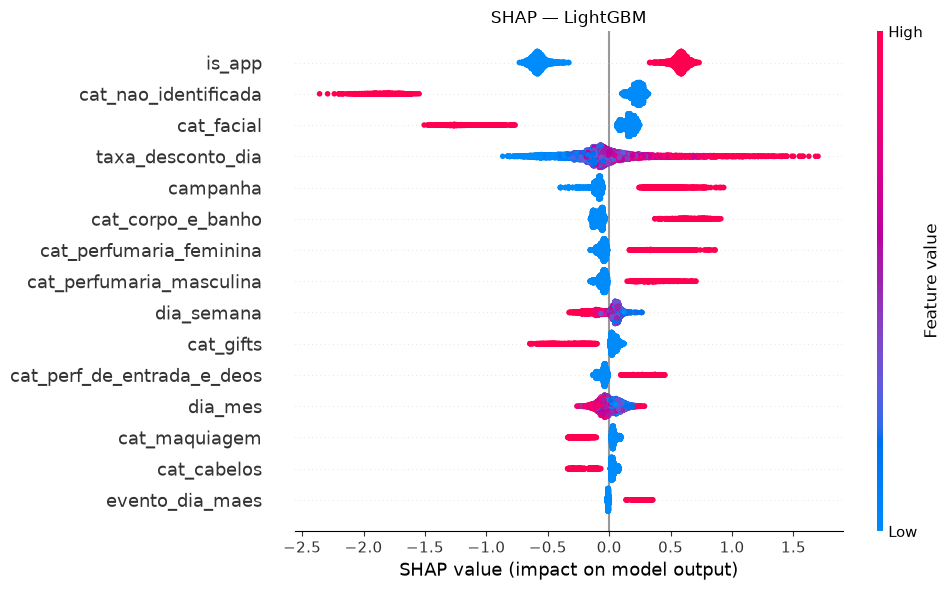

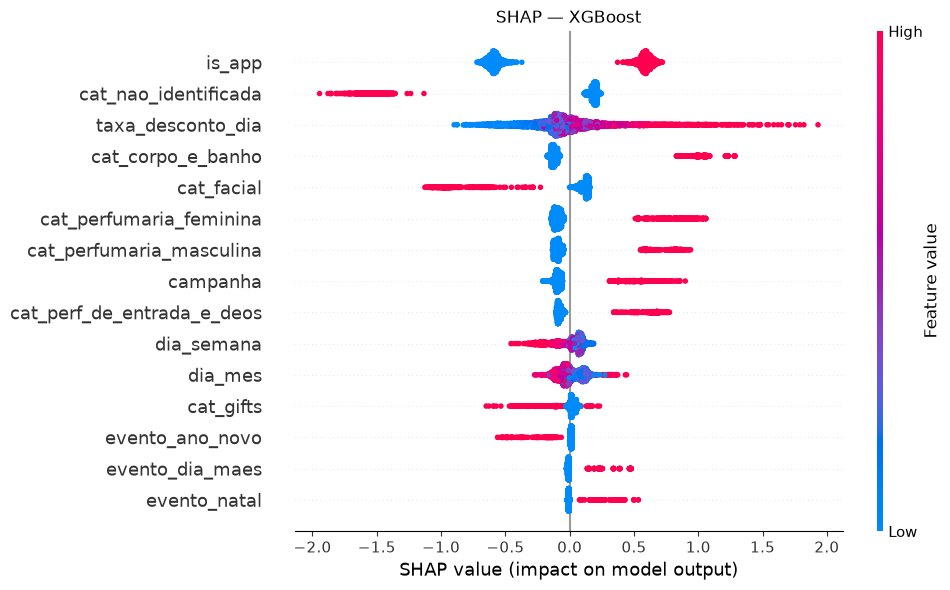

In [22]:
import shap

shap_lightgbm = shap.TreeExplainer(modelo_lightgbm).shap_values(X_lightgbm)
shap_xgboost = shap.TreeExplainer(modelo_xgboost).shap_values(X_xgboost)

for nome, valores, X in [("LightGBM", shap_lightgbm, X_lightgbm), ("XGBoost", shap_xgboost, X_xgboost)]:
    plt.figure()
    shap.summary_plot(valores, X, max_display=15, show=False, plot_size=(10, 6))
    plt.title(f"SHAP — {nome}")
    plt.tight_layout()
    plt.show()

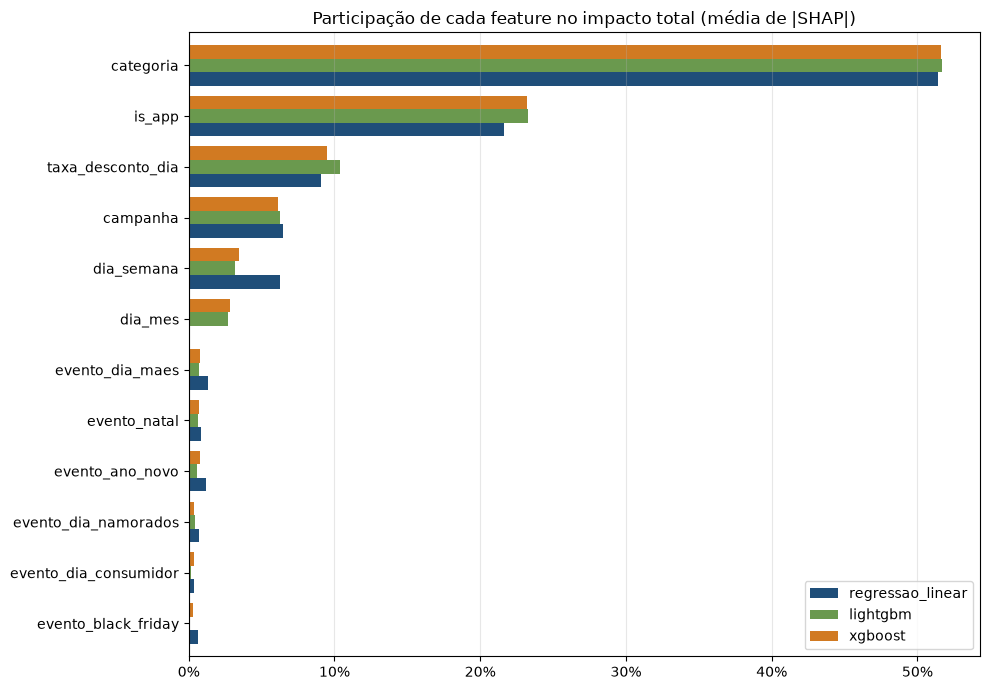

,regressao_linear,lightgbm,xgboost
categoria,51.4%,51.7%,51.6%
is_app,21.6%,23.3%,23.2%
taxa_desconto_dia,9.1%,10.4%,9.5%
campanha,6.5%,6.3%,6.2%
dia_semana,6.3%,3.2%,3.5%
dia_mes,0.0%,2.7%,2.8%
evento_dia_maes,1.3%,0.7%,0.8%
evento_natal,0.8%,0.6%,0.7%
evento_ano_novo,1.2%,0.6%,0.8%
evento_dia_namorados,0.7%,0.4%,0.4%


In [23]:
from gb_ml.features import matriz_linear

X_linear = matriz_linear(df, params_linear["interacao"])[modelo_linear.params.index.drop("const")]
# SHAP de modelo linear: coeficiente × (valor − média)
shap_linear = (X_linear - X_linear.mean()) * modelo_linear.params.drop("const")


def agrupar(nome_coluna: str) -> str:
    if nome_coluna.startswith(("cat_", "app_x_cat_")):
        return "categoria"
    if nome_coluna.startswith("dia_semana"):
        return "dia_semana"
    if nome_coluna.startswith(("lag_", "mm")):
        return "lags (histórico)"
    return nome_coluna


importancia = {}
for nome, valores, X in [("regressao_linear", shap_linear.to_numpy(), X_linear),
                         ("lightgbm", shap_lightgbm, X_lightgbm),
                         ("xgboost", shap_xgboost, X_xgboost)]:
    impacto = pd.Series(np.abs(valores).mean(axis=0), index=X.columns)
    impacto = impacto.groupby(impacto.index.map(agrupar)).sum()
    importancia[nome] = impacto / impacto.sum()
importancia = pd.DataFrame(importancia).fillna(0).sort_values("lightgbm")

ax = importancia.plot.barh(figsize=(10, 7), color=[CORES_MODELO[m] for m in importancia.columns], width=0.8)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("Participação de cada feature no impacto total (média de |SHAP|)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()
display(importancia.sort_values("lightgbm", ascending=False).map(lambda v: f"{v:.1%}"))

### Diagnóstico

- **Os três modelos concordam na ordem de importância:**
  - **Categoria e canal** explicam cerca de 75% do impacto. São o nível de cada série.
  - **Taxa de desconto** (~10%) e **campanha** (~6%) explicam a variação ao longo do tempo.
  - **Dia da semana** fica com 3–6%.
- **Desconto:** no beeswarm, desconto alto (vermelho) empurra a previsão para cima, e o efeito cresce de forma não linear nas taxas acima de ~50%.
- **Eventos:** pesam pouco na média porque ficam ligados em poucos dias, mas nesses dias o impacto é grande (Dia das Mães, Natal, Ano Novo negativo).
- **Black Friday:** nas árvores, a flag `black_friday` tem impacto ~0%. Elas atribuem o pico de novembro à campanha e ao desconto. Na regressão linear, a flag mantém um efeito próprio de +33%. Para a próxima Black Friday, isso é relevante: a regressão carrega o efeito do evento de forma explícita e proporcional ao nível de vendas.

# 10. Sensibilidade à premissa do desconto

No backtest usamos a taxa de desconto **realizada** de cada dia, como se o time de desconto acertasse a previsão em cheio. Na prática ela terá erro. Para medir o risco, refazemos o teste trocando, **só nos dias previstos**, a taxa diária pela **média do mês**. Isso simula um time que informa apenas um plano mensal, sem os picos de cada dia.

In [24]:
taxa_mensal = df.groupby(df["data"].dt.to_period("M"))["taxa_desconto_dia"].transform("mean")


def com_desconto_mensal(ajustar_prever):
    def ajustar_prever_mensal(treino, teste):
        return ajustar_prever(treino, teste.assign(taxa_desconto_dia=taxa_mensal.loc[teste.index]))
    return ajustar_prever_mensal


fabricas = {
    "regressao_linear": linear(**params_linear),
    "lightgbm": lightgbm(**params_lightgbm),
    "xgboost": xgboost(**params_xgboost),
}
sensibilidade = []
for nome, ajustar_prever in fabricas.items():
    mensal = resumo_backtest(rodar_backtest(df, folds_teste, com_desconto_mensal(ajustar_prever)))
    sensibilidade.append({
        "modelo": nome,
        "wape_dia (desconto diário)": comparacao.loc[nome, "wape_dia"],
        "wape_dia (desconto mensal)": mensal["wape_dia"],
        "vies_dia (desconto mensal)": mensal["vies_dia"],
    })
sensibilidade = pd.DataFrame(sensibilidade).set_index("modelo")
sensibilidade["piora (p.p.)"] = 100 * (sensibilidade["wape_dia (desconto mensal)"] - sensibilidade["wape_dia (desconto diário)"])
sensibilidade[f"wape_dia {MELHOR_BASELINE}"] = comparacao.loc[MELHOR_BASELINE, "wape_dia"]
display(sensibilidade)

,wape_dia (desconto diário),wape_dia (desconto mensal),vies_dia (desconto mensal),piora (p.p.),wape_dia mm7
modelo,,,,,
regressao_linear,0.3102,0.2902,-0.0985,-1.9958,0.3576
lightgbm,0.2704,0.2902,-0.0292,1.9827,0.3576
xgboost,0.2893,0.3072,-0.0009,1.7897,0.3576


### Diagnóstico

- **Árvores:** usar a taxa média do mês em vez da diária piora o WAPE em ~2 p.p. (LightGBM de 27,0% para 29,0%; XGBoost de 28,9% para 30,7%). Todos continuam bem melhores que o mm7 (35,8%).
- **Regressão linear:** **melhora** 2 p.p. com a taxa mensal. Os picos diários de desconto (como 29–30/05) fazem a regressão exagerar o volume, e a média do mês suaviza isso.
- **Conclusão:** a premissa do desconto é robusta. Mesmo um plano só mensal do time de desconto mantém o ganho sobre o baseline. O detalhe diário ajuda as árvores, mas não é crítico.

# 11. Conclusões e próximos passos

**Resultado**
- **Modelo recomendado: LightGBM**, com o menor erro do total do dia (WAPE de 27% contra 36% do melhor baseline, um ganho de 24%). Ressalva: o viés de −10,5% está no limite do gate e vem da semana do Dia das Mães, inédita no treino.
- **Regressão linear como modelo de apoio:** erra mais (31%), mas tem o menor viés e explica cada efeito com intervalo de confiança. É a melhor ferramenta para conversar com o negócio ("+10 p.p. de desconto ≈ +38% de volume").
- **Lags:** foram testados e descartados pelos três ajustes. Com 8 meses e mudanças fortes de patamar (Black November), o histórico recente atrapalha mais do que ajuda.

**Estaremos preparados para a próxima Black Friday?** Em parte:
- As flags são calculadas por regra, então a Black Friday de 27/11/2026 já tem flag.
- A regressão linear aprendeu um efeito proporcional (+33% na semana, além da campanha). As árvores atribuem o pico à campanha e ao desconto.
- O Dia das Mães mostrou o risco: na primeira vez que um evento aparece, o modelo erra muito. Na segunda vez, já existe histórico.
- Como cada evento só aconteceu uma vez, os efeitos são estimativas iniciais. Devem ser reestimados após cada nova ocorrência.

**Próximos passos**
1. **Separar a Black November das demais campanhas,** ou receber do negócio a intensidade de cada campanha. Hoje uma única flag mistura um efeito de 4× com um de 2×, e por isso a campanha de maio foi superestimada.
2. **Agregar a previsão das séries pequenas** (Facial, `NAO_IDENTIFICADA`) num nível mais alto, ou reconciliar com o total, já que o erro delas é alto.
3. **Gravar previsões e métricas de cada execução no BigQuery** (com id_execucao, data e versão do código) e monitorar o WAPE semana a semana contra o baseline.
4. **Retreinar quinzenalmente** (o mesmo ritmo do teste faseado) e reestimar os efeitos de eventos após cada ocorrência.